In [1]:
import numpy as np

# Package containing helper functions related to Beta distributions
from scipy.stats import beta

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [15]:
# prior
# 𝑥-coordinates of the PDF curves for plotting
ps = np.linspace(0, 1, 101)

# Hyperparameters of the prior
prior_a = 1
prior_b = 1

# 𝑦-coordinates of the prior PDF curve
prior = beta.pdf(ps, prior_a, prior_b)

# observed data
k = 3  # number of tea drinkers
n = 5  # number of people surveyed

In [17]:
# Hyperparameters of the posterior
post_a = prior_a + k

# posterior
post_b = prior_b + (n - k)

# 𝑦-coordinates of the posterior PDF curve
posterior = beta.pdf(ps, post_a, post_b)

# NOTE: STATEMENT ORDER DOES NOT MATCH TEXT

In [19]:
post_a, post_b

(4, 3)

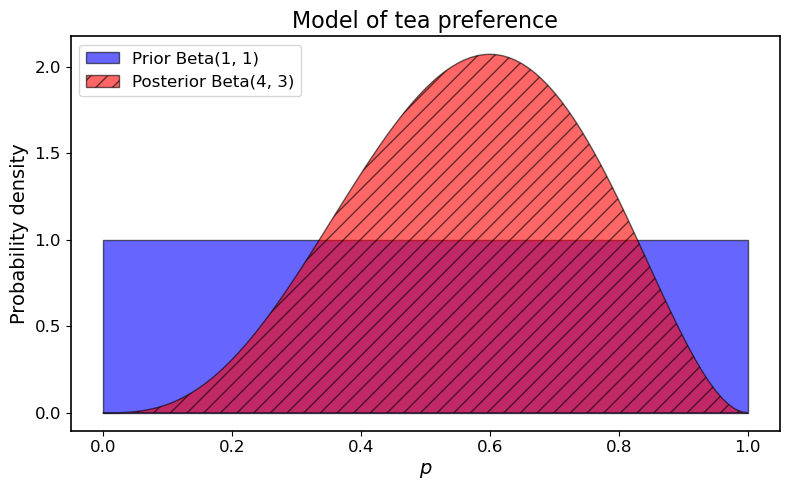

In [21]:
width = 0.1

plt.figure(figsize=(8, 5))

plt.fill_between(
    ps, 
    0, 
    prior, 
    color="blue", 
    alpha=0.6, 
    label="Prior Beta(1, 1)", 
    edgecolor="k",
)
plt.fill_between(
    ps, 
    posterior, 
    color='red', 
    alpha=0.6, 
    label='Posterior Beta(4, 3)', 
    hatch="//", 
    edgecolor="k",
)

plt.xlabel(r'$p$')
plt.ylabel('Probability density')
plt.title('Model of tea preference')
# plt.xticks(ps)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
1 - beta.cdf(0.8, post_a, post_b)

0.09887999999999997

In [25]:
beta.cdf(0.4, post_a, post_b)- beta.cdf(0.2, post_a, post_b)

0.16224000000000002

# Illustrations

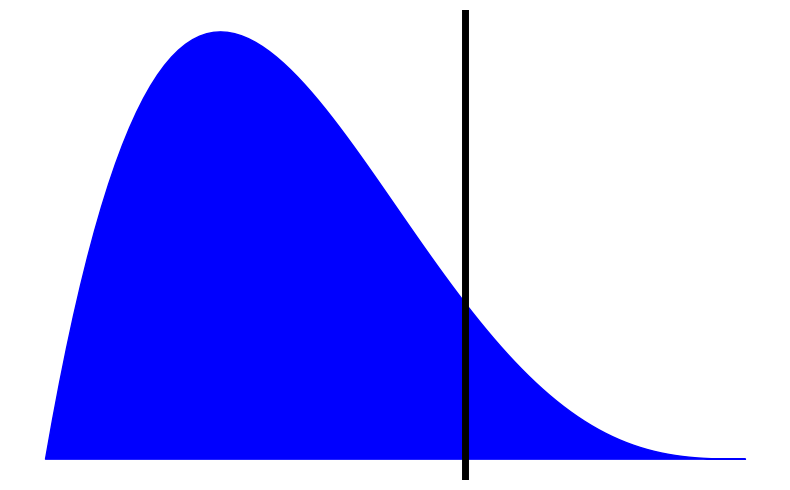

In [28]:
plt.figure(figsize=(8, 5))

# plt.fill_between(ps, 0, prior, color="blue", label="Prior", edgecolor="k")
plt.fill_between(
    ps, 
    beta(2, 4).pdf(ps), 
    color='blue', 
    # label='Posterior'
)
plt.fill_between(ps, posterior, color='red', alpha=0., hatch="//", edgecolor="k")
plt.axvline(0.6, c="k", linewidth=5, label="Data")

plt.axis("off")
# plt.legend(frameon=False)

plt.tight_layout()
plt.show()

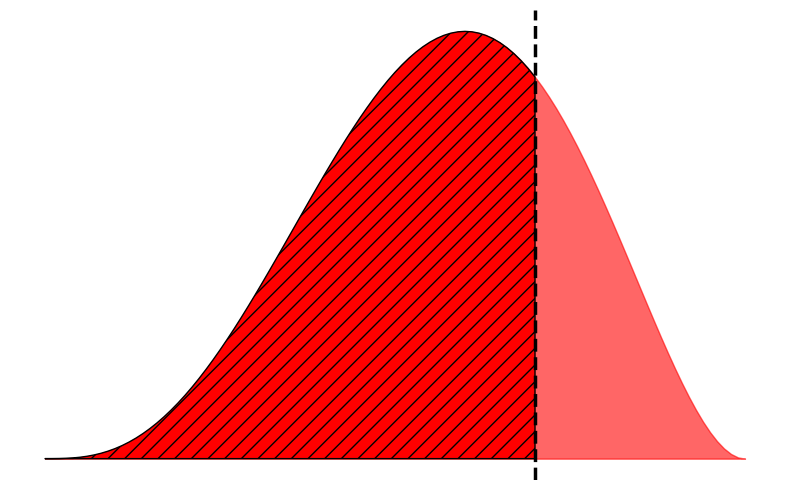

In [30]:
plt.figure(figsize=(8, 5))

# plt.fill_between(ps, 0, prior, color="blue", label="Prior", edgecolor="k")
plt.fill_between(ps, posterior, color='red', alpha=0.6, label='Posterior')
plt.fill_between(ps, posterior, color='red', alpha=0., label='Posterior', hatch="//", edgecolor="k")

plt.axvline(0.7, linestyle="--", c="k")
plt.fill_between(ps[ps <= 0.705], posterior[ps <= 0.705], color='red', label='Posterior', hatch="//", edgecolor="k")

plt.axis("off")

plt.tight_layout()
plt.show()

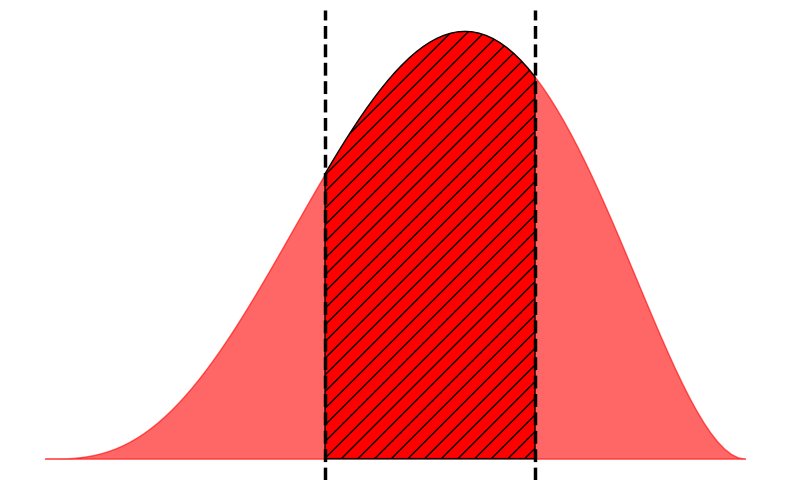

In [32]:
plt.figure(figsize=(8, 5))

# plt.fill_between(ps, 0, prior, color="blue", label="Prior", edgecolor="k")
plt.fill_between(ps, posterior, color='red', alpha=0.6, label='Posterior')
plt.fill_between(ps, posterior, color='red', alpha=0., label='Posterior', hatch="//", edgecolor="k")

plt.axvline(0.7, linestyle="--", c="k")
plt.axvline(0.4, linestyle="--", c="k")
plt.fill_between(ps[(ps <= 0.705) * (ps >= 0.4)], posterior[(ps <= 0.705) * (ps >= 0.4)], color='red', label='Posterior', hatch="//", edgecolor="k")

plt.axis("off")

plt.tight_layout()
plt.show()

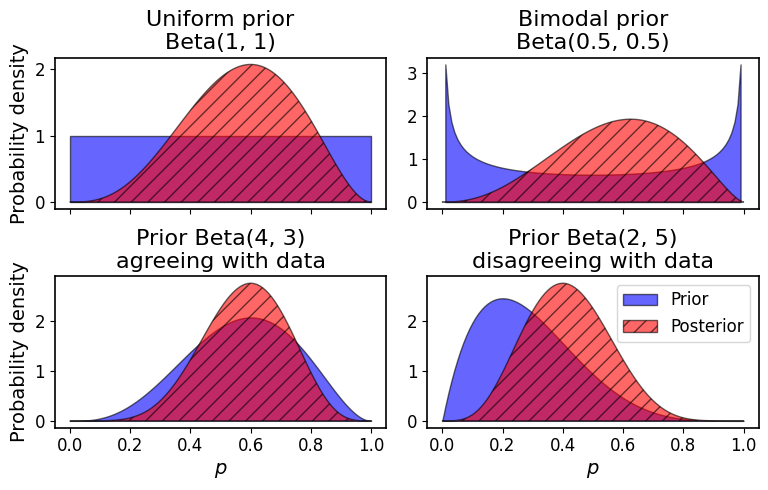

In [11]:
prior_hyperparams = [
    (1, 1),
    (0.5, 0.5),
    (4, 3),
    (2, 5)
]
descriptions = [
    "Uniform prior\nBeta(1, 1)",
    "Bimodal prior\nBeta(0.5, 0.5)",
    "Prior Beta(4, 3)\nagreeing with data",
    "Prior Beta(2, 5)\ndisagreeing with data",
]

fig, ax = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for i, (prior_a, prior_b) in enumerate(prior_hyperparams):
    this_ax = ax[i // 2][i % 2]
    post_a = prior_a + k
    post_b = prior_b + (n - k)

    prior = beta.pdf(ps, prior_a, prior_b)
    posterior = beta.pdf(ps, post_a, post_b)

    this_ax.fill_between(
        ps, 
        0, 
        prior, 
        color="blue", 
        alpha=0.6, 
        label="Prior", 
        edgecolor="k",
    )
    this_ax.fill_between(
        ps, 
        posterior, 
        color='red', 
        alpha=0.6, 
        label='Posterior', 
        hatch="//", 
        edgecolor="k",
    )

    this_ax.set_title(descriptions[i])

ax[1, 1].legend()

ax[0, 0].set_ylabel("Probability density")
ax[1, 0].set_ylabel("Probability density")

ax[1, 0].set_xlabel(r"$p$")
ax[1, 1].set_xlabel(r"$p$")

plt.tight_layout()
plt.show()